# PEMFC dynamic response — three-step current load (5 A → 7 A → 10 A)

Demonstrates the internal-state evolution of the **cathode gas channel** (Ucell, C_O2_cgc, C_v_cgc, C_N2) when a smoothed three-step load profile is applied. The model is the 1-D `PEMFC` (dual-scale, no auxiliary system); the inlet/outlet boundaries are clamped at the design operating point.

Each of the four panels shows the same load-current trace (orange, left axis) overlaid with one cathode-channel state variable (right axis), so the user can see how each species concentration relaxes after each current step.

In [18]:
import sys
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# --------------- Project imports ------------------------- #
from config.initialize import parameters, operating_inputs, init_x
from config.settings   import solver_variable_names, solver_flux_names
from model.model       import PEMFC

warnings.filterwarnings("ignore")

## 1 — Three-step current profile (with 60 s warmup)

Two `tanh` transitions, each centred at a switch time, smooth the otherwise discontinuous step so the solver does not see a stiff boundary. Total cell current $I(t)$ in Amperes is converted to current density $i = I/A_{act}$ for the model. The first **60 s are a warmup** at the lowest current so the model settles from its initial state before the visible steps begin; they are sliced off in the final plot.

- $0 \le t < 60\,\text{s}$: $I = 5$ A  *(warmup — not plotted)*
- $60 \le t < 120\,\text{s}$: $I = 5$ A  *(step #1 — 60 s)*
- $120 \le t < 180\,\text{s}$: $I = 7$ A  *(step #2 — 60 s)*
- $180 \le t \le 240\,\text{s}$: $I = 10$ A  *(step #3 — 60 s)*

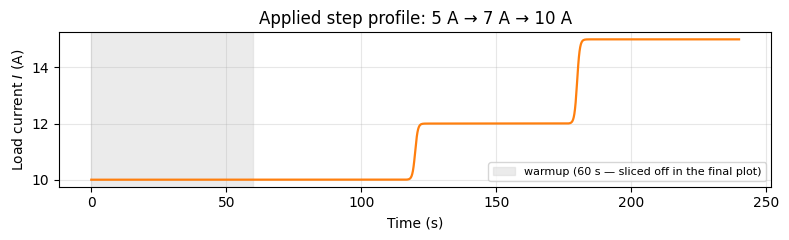

In [19]:
Aact = parameters["Aact"]
I_LEVELS   = [10.0, 12.0, 15.0]      # A     -- three step levels
T_WARMUP   = 60.0                  # s     -- initial settling phase at I_LEVELS[0]
T_STEP     = 60.0                  # s     -- duration of each visible step
T_SWITCHES = [T_WARMUP + T_STEP,                  # 120 s : 10 A -> 12 A
              T_WARMUP + 2 * T_STEP]              # 180 s : 12 A -> 15 A
TAU_SMOOTH = 1.0                   # s     -- transition smoothing time
T_SPAN     = (0.0, T_WARMUP + 3 * T_STEP)         # (0, 240) s

def three_step_profile(t):
    I = I_LEVELS[0]
    I += 0.5 * (I_LEVELS[1] - I_LEVELS[0]) * (1 + np.tanh((t - T_SWITCHES[0]) / TAU_SMOOTH))
    I += 0.5 * (I_LEVELS[2] - I_LEVELS[1]) * (1 + np.tanh((t - T_SWITCHES[1]) / TAU_SMOOTH))
    return I / Aact   # A / m^2

# Quick preview of the profile
t_prev = np.linspace(T_SPAN[0], T_SPAN[1], 1000)
I_prev = np.array([three_step_profile(t) for t in t_prev]) * Aact   # A
plt.figure(figsize=(8, 2.5))
plt.plot(t_prev, I_prev, color="tab:orange", linewidth=1.6)
plt.axvspan(0, T_WARMUP, color="0.85", alpha=0.5,
            label=f"warmup ({T_WARMUP:.0f} s — sliced off in the final plot)")
plt.xlabel("Time (s)")
plt.ylabel("Load current $I$ (A)")
plt.title("Applied step profile: 5 A → 7 A → 10 A")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2 — Run the dual-scale model (no auxiliary system)

Inlet/outlet boundaries are clamped at the design operating point — $T_{fc}=353.15$ K, $P_{a,des}=P_{c,des}=1.8\times10^{5}$ Pa, $\Phi_{a,des}=0$, $\Phi_{c,des}=0.85$, $S_a=1.2$, $S_c=2.0$. With `aux_system=False` the runner solves the 1-D PEMFC ODEs without integrating the compressor / manifold dynamics.

In [20]:
params = deepcopy(parameters)
params["aux_system"] = False     # 1-D model, no balance-of-plant

op_inputs = deepcopy({k: v for k, v in operating_inputs.items() if k != "current_density"})
op_inputs["current_density"] = three_step_profile

model = PEMFC(param=params, operating_inputs=op_inputs,
              variable_names=solver_variable_names,
              flux_names=solver_flux_names)
y0  = init_x(op_inputs, params)
sol = solve_ivp(model.dxdt, T_SPAN, y0, method="BDF", max_step=0.5)
model._recovery(sol)

print(f"Solver success : {sol.success}")
print(f"n_steps        : {len(sol.t)}")
print(f"Final Ucell    : {model.echem_traj['Ucell'][-1]:.4f} V")

Solver success : True
n_steps        : 557
Final Ucell    : 0.7335 V


## 3 — Four-panel dynamic response (warmup excluded)

The first **60 s initialization phase** is not shown in the final figure. The plot time axis starts after warmup, so each visible step is exactly **60 s** (0-60, 60-120, 120-180 s).

Each panel:
- **Left axis** — load current $I$ (A)
- **Right axis** — one cathode gas-channel state variable

with proper units in every label.

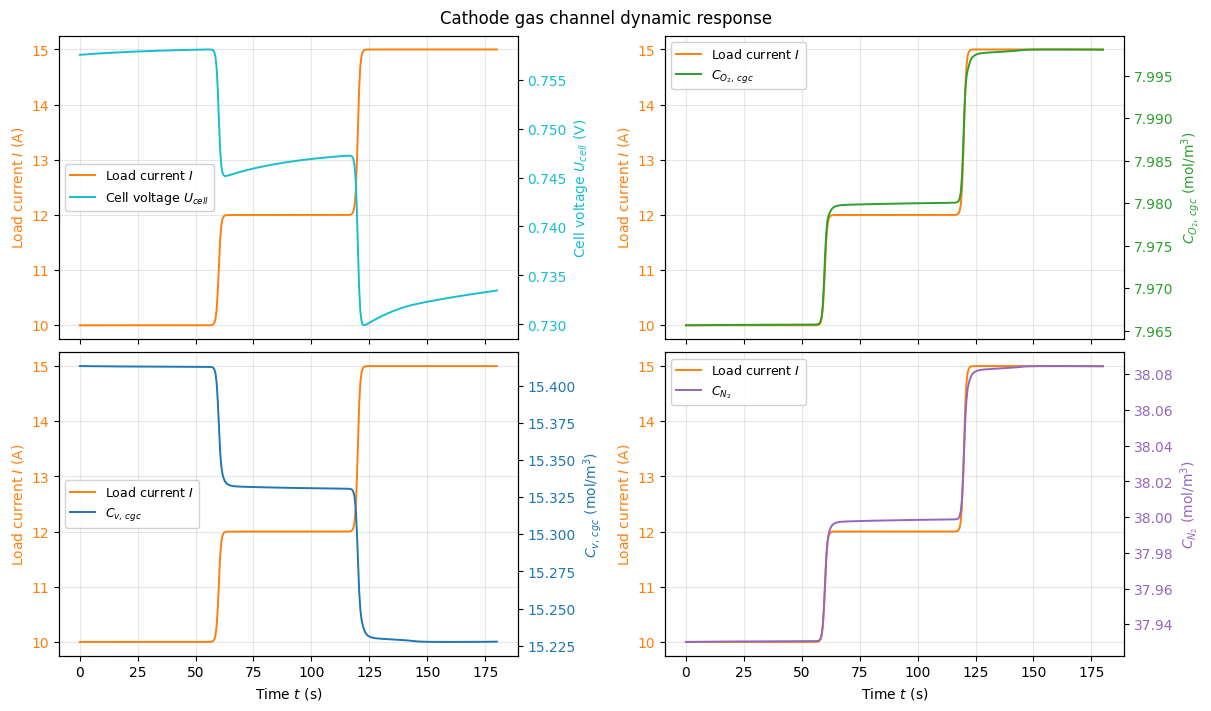

In [24]:
# ---- Extract trajectories --------------------------------------------
t       = np.asarray(model.variables["t"])
i_fc    = np.asarray(model.echem_traj["i_fc"])      # A / m^2
Ucell   = np.asarray(model.echem_traj["Ucell"])     # V (per cell)
I_load  = i_fc * Aact                                # A
C_O2    = np.asarray(model.variables["C_O2_cgc"])    # mol / m^3
C_v     = np.asarray(model.variables["C_v_cgc"])     # mol / m^3
C_N2    = np.asarray(model.variables["C_N2"])        # mol / m^3

# ---- Ignore warmup phase in plots ------------------------------------
t_warmup = T_WARMUP if "T_WARMUP" in globals() else 60.0
mask = t >= t_warmup

# Plot time is re-zeroed so each visible step is 60 s: 0-60, 60-120, 120-180 s
t_plot = t[mask] - t_warmup
I_plot = I_load[mask]
U_plot = Ucell[mask]
O2_plot = C_O2[mask]
Cv_plot = C_v[mask]
N2_plot = C_N2[mask]

# ---- 2 x 2 figure with twin y-axes -----------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, constrained_layout=True)

def _twin_panel(ax, t_axis, i_axis, y_state, y_label, color, state_label, legend_loc="upper left"):
    """Left axis = load current (A). Right axis = state variable."""
    n = min(len(t_axis), len(i_axis))
    l1, = ax.plot(t_axis[:n], i_axis[:n], color="tab:orange", linewidth=1.4, label="Load current $I$")
    ax.set_ylabel("Load current $I$ (A)", color="tab:orange")
    ax.tick_params(axis="y", labelcolor="tab:orange")
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    m = min(len(t_axis), len(y_state))
    l2, = ax2.plot(t_axis[:m], y_state[:m], color=color, linewidth=1.4, label=state_label)
    ax2.set_ylabel(y_label, color=color)
    ax2.tick_params(axis="y", labelcolor=color)

    ax.legend(handles=[l1, l2], loc=legend_loc, fontsize=9, frameon=True, framealpha=0.9)
    return ax2

_twin_panel(axes[0, 0], t_plot, I_plot, U_plot,
            y_label="Cell voltage $U_{cell}$ (V)",
            color="tab:cyan",
            state_label="Cell voltage $U_{cell}$",
            legend_loc="center left")
_twin_panel(axes[0, 1], t_plot, I_plot, O2_plot,
            y_label="$C_{O_2,\\,cgc}$ (mol/m$^3$)",
            color="tab:green",
            state_label="$C_{O_2,\\,cgc}$")
_twin_panel(axes[1, 0], t_plot, I_plot, Cv_plot,
            y_label="$C_{v,\\,cgc}$ (mol/m$^3$)",
            color="tab:blue",
            state_label="$C_{v,\\,cgc}$",
            legend_loc="center left")
_twin_panel(axes[1, 1], t_plot, I_plot, N2_plot,
            y_label="$C_{N_2}$ (mol/m$^3$)",
            color="tab:purple",
            state_label="$C_{N_2}$")

for ax in axes[1, :]:
    ax.set_xlabel("Time $t$ (s)")

fig.suptitle("Cathode gas channel dynamic response", fontsize=12)
plt.show()